In [77]:
from frites.simulations import StimSpecAR
import matplotlib.pyplot as plt
from frites.config import CONFIG
from frites.conn import conn_dfc, define_windows, plot_windows
from frites.conn import (conn_covgc, conn_reshape_directed,
                         conn_reshape_undirected)
import numpy as np

## 1)	Auto-regressive model

Simulate a simple autoregressive model composed of a source signal X and a target signal Y (pairwise AR model).

Here, we use the class :class:`frites.simulations.StimSpecAR` to simulate an
stimulus-specific autoregressive model. For the pairwise models, you can
choose :

    * 'hga' : high-gamma burst
    * 'osc_40' / 'osc_20' : respectivelly 20hz and 40hz oscillations
    * 'ding_2' : pairwise Ding's model :cite:`ding2006granger`

In the current project, we choose the 'osc_40' model. 

Here is the code to generate 100 trials with a three stimuli and plot the single trial data and causal coupling over time.

In [135]:
# Here are the parameters of the simulation
ar_type = 'osc_40'  # 40hz oscillations
n_stim = 3          # number of stimulus
n_epochs = 100       # number of epochs per stimulus
n_times = 400
stim_onset = 100
dt = 100
sfreq = 200

ss = StimSpecAR()
ar = ss.fit(ar_type=ar_type, n_times=n_times, stim_onset=stim_onset, dt=dt, n_epochs=n_epochs, n_stim=n_stim, sf=sfreq, n_std=5)

40Hz oscillations AR model (n_times=400, n_epochs=100, n_stim=3, random_state=7070)


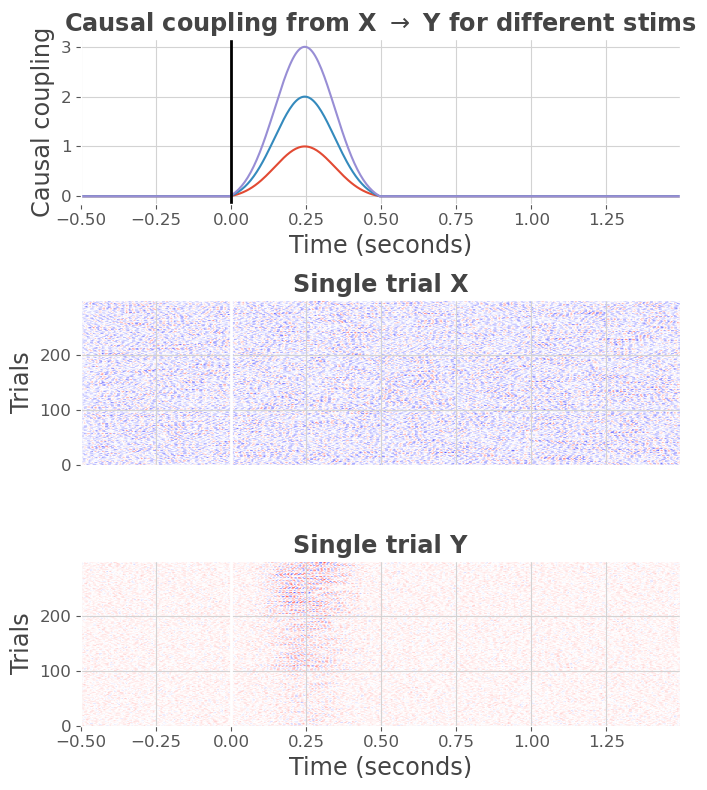

In [136]:
# Plot the simulated data 
plt.figure(figsize=(7, 8))
ss.plot(cmap='bwr')
plt.tight_layout()
plt.show()

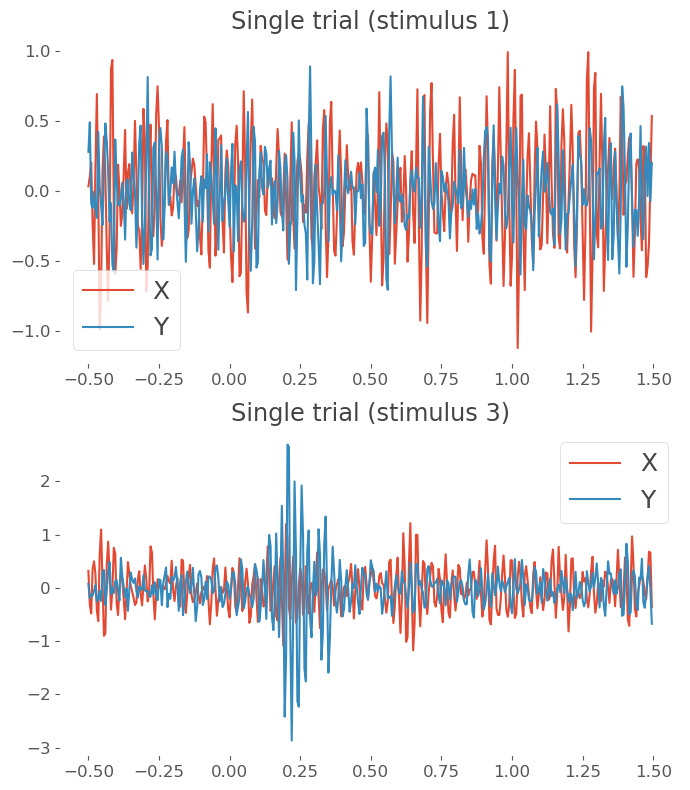

In [137]:
# Plot X and Y for a single trial
plt.figure(figsize=(7, 8))

plt.subplot(211)
plt.plot(ar.times, ar[0, 0, :], label='X')
plt.plot(ar.times, ar[0, 1, :], label='Y')
plt.grid()
plt.legend()
title = 'Single trial (stimulus 1)'
plt.title(title)
plt.tight_layout()

plt.subplot(212)
plt.plot(ar.times, ar[251, 0, :], label='X')
plt.plot(ar.times, ar[251, 1, :], label='Y')
plt.grid()
plt.legend()
title = 'Single trial (stimulus 3)'
plt.title(title)
plt.tight_layout()

plt.show()


The equation used to simulate the model is at line 136 and 138 of sim_ar.py file.


    if ar_type == 'osc_40':    # bivariate data oscillating at 40Hz
        a1 = [.55, -.8]
        a2 = [.35, -.5]
        a12 = [.5, 0.]

    # AR core
        # - x1 = noise + gain + a1 * past_x1
        # - x2 = noise + a2 * past_x2 + coupling * past_x1
        x[:, t] = n1[:, t] + g[:, t] + (x[:, _sl_a1] @ a1)
        y[:, t] = n2[:, t] + (y[:, _sl_a2] @ a2) + c2[:, t] * (
            x[:, _sl_a12] @ a12)

## 2) Single-trial time-resolved (dynamic) Functional Connectivity

Now, we take the data simulated in 1b and estimate dynamic functional connectivity between X and Y with the following parameters: window length = 0.75 seconds, win_step = 0.02  seconds

a)	Computed the DFC for each trial and plot the average time course across trials

b)	Test different window_length values and plot different examples, try to interpret the results



In [144]:
# Define windows
slwin_len = .7   # 500ms window length
slwin_step = .02  # 20ms between consecutive windows
win_sample = define_windows(ar.times.data, slwin_len=slwin_len,
                            slwin_step=slwin_step)[0]

Defining temporal windows (sfreq=199.99999999999983)
    Definition of sliding windows (len=0.7, start=-0.5, stop=1.495, step=0.02)


Defining links (n_roi=2; directed=False; net=False, nb_min_links=None)
    Sorting roi names
Gaussian Copula Mutual Information Estimator (mi_type=cc, copnorm=False, biascorrect=False, demeaned=False)
Computing DFC between 1 pairs (gcrn=False)


  0%|          | Estimating DFC : 0/1 [00:00<?,       ?it/s]

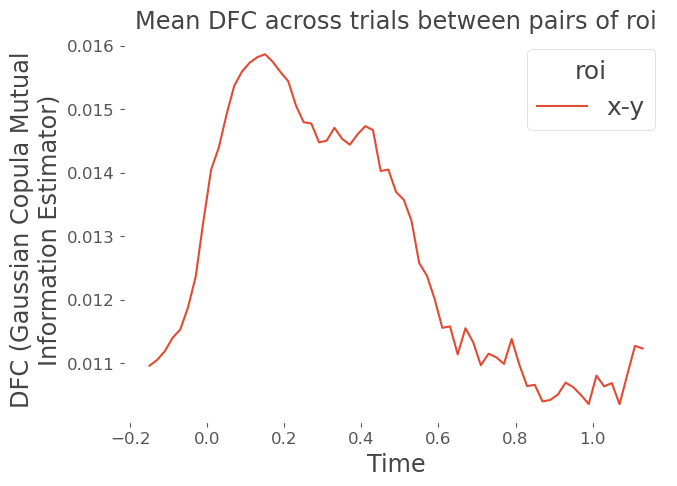

In [145]:

# compute the DFC on sliding windows
dfc = conn_dfc(ar, times='times', roi='roi', win_sample=win_sample)
# compute DFC
#dfc = conn_dfc(ar, win_sample, times=ar.times.data, roi=ar.roi)

plt.figure(figsize=(7, 5))
# plt.plot(times_p, dfc.mean('trials').T)
dfc.mean('trials').plot.line(x='times', hue='roi')
plt.xlabel('Time')
plt.title("Mean DFC across trials between pairs of roi")
plt.grid()
plt.show()